# Replication: ProPublica's "Machine Bias" — COMPAS Recidivism Analysis

## Background

In May 2016, **ProPublica** published an investigation titled *"Machine Bias"* that examined **COMPAS** (Correctional Offender Management Profiling for Alternative Sanctions), a commercial algorithm widely used in the U.S. criminal justice system to predict a defendant's likelihood of reoffending (recidivism).

Their key findings:
- **Black defendants** were far more likely than white defendants to be **falsely flagged as future criminals** (higher false positive rate)
- **White defendants** were more likely than black defendants to be **incorrectly labeled as low risk** despite going on to reoffend (higher false negative rate)
- The algorithm's overall accuracy was roughly similar across races, but **the types of errors it made were systematically different**

This notebook **replicates** their core analysis using the same dataset from Broward County, Florida.

### References
- ProPublica Article: [Machine Bias](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing)
- Original Analysis: [GitHub Repository](https://github.com/propublica/compas-analysis)

---
## Section 1: Setup & Data Loading

We start by importing all the libraries we'll need and loading the dataset.

- **pandas** — for data manipulation and analysis
- **numpy** — for numerical operations
- **matplotlib** — for creating charts and visualizations
- **scikit-learn** — for building and evaluating a logistic regression model

In [1]:
# ============================================================
# Section 1: Import libraries and load data
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Set plot style for cleaner visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Create output directory for saved figures
os.makedirs('output', exist_ok=True)

print("All libraries loaded successfully!")

All libraries loaded successfully!


### Load the COMPAS Dataset

The dataset comes from Broward County, Florida and was obtained by ProPublica through a public records request. It contains information on ~7,000 defendants who were scored by the COMPAS algorithm between 2013 and 2014.

Key columns:
- `decile_score` — COMPAS risk score (1–10, higher = higher predicted risk)
- `score_text` — risk category: Low, Medium, or High
- `two_year_recid` — whether the defendant actually reoffended within 2 years (1 = yes, 0 = no)
- `race` — defendant's race
- `age`, `sex`, `priors_count`, `c_charge_degree` — other defendant/case characteristics

In [2]:
# Load the dataset from our local copy
# (Originally from: https://github.com/propublica/compas-analysis)
df_raw = pd.read_csv('data/compas-scores-two-years.csv')

print(f"Raw dataset shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
df_raw.head()

Raw dataset shape: 7214 rows, 53 columns

Column names:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']

First 5 rows:


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


---
## Section 2: Data Preparation — Replicating ProPublica's Filtering

ProPublica applied specific filters to the raw data to ensure a clean, comparable sample. We replicate their exact criteria here:

1. **`days_b_screening_arrest` between -30 and 30** — Only include cases where the COMPAS screening happened within 30 days of arrest. This ensures the score is actually relevant to the arrest in question.

2. **`is_recid` != -1** — Remove cases with missing recidivism information.

3. **`c_charge_degree` != 'O'** — Remove ordinary traffic offenses, which are not meaningful for recidivism analysis.

4. **`score_text` != 'N/A'** — Remove cases where COMPAS did not produce a valid score.

In [3]:
# ============================================================
# Section 2: Apply ProPublica's exact filtering criteria
# ============================================================

print(f"Starting with {len(df_raw)} rows\n")

# Make a copy so we don't modify the original
df = df_raw.copy()

# Filter 1: COMPAS screening must be within 30 days of arrest
# Replicating ProPublica's filtering: exclude cases where screening
# was too far from the arrest date (not relevant to the charge)
df = df[
    (df['days_b_screening_arrest'] >= -30) &
    (df['days_b_screening_arrest'] <= 30)
]
print(f"After filtering days_b_screening_arrest: {len(df)} rows")

# Filter 2: Remove rows with missing recidivism data
df = df[df['is_recid'] != -1]
print(f"After filtering is_recid != -1: {len(df)} rows")

# Filter 3: Remove ordinary traffic offenses (not relevant to recidivism)
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering out traffic offenses: {len(df)} rows")

# Filter 4: Remove cases where COMPAS score is N/A
df = df[df['score_text'] != 'N/A']
print(f"After filtering score_text != N/A: {len(df)} rows")

print(f"\n=== Final filtered dataset: {len(df)} rows ===")

Starting with 7214 rows

After filtering days_b_screening_arrest: 6172 rows
After filtering is_recid != -1: 6172 rows
After filtering out traffic offenses: 6172 rows
After filtering score_text != N/A: 6172 rows

=== Final filtered dataset: 6172 rows ===


### Demographic Breakdown

Let's look at the racial and demographic composition of the filtered dataset, as well as the overall recidivism rate.

In [4]:
# Show the racial breakdown of the dataset
print("=" * 50)
print("DEMOGRAPHIC BREAKDOWN OF FILTERED DATASET")
print("=" * 50)

print("\n--- Race Distribution ---")
race_counts = df['race'].value_counts()
race_pcts = df['race'].value_counts(normalize=True) * 100
for race in race_counts.index:
    print(f"  {race}: {race_counts[race]} ({race_pcts[race]:.1f}%)")

print("\n--- Sex Distribution ---")
sex_counts = df['sex'].value_counts()
for sex in sex_counts.index:
    print(f"  {sex}: {sex_counts[sex]}")

print("\n--- Age Statistics ---")
print(f"  Mean age: {df['age'].mean():.1f}")
print(f"  Median age: {df['age'].median():.0f}")

print("\n--- Overall Recidivism Rate ---")
recid_rate = df['two_year_recid'].mean() * 100
print(f"  {recid_rate:.1f}% of defendants reoffended within 2 years")

print("\n--- Recidivism Rate by Race (two largest groups) ---")
for race in ['African-American', 'Caucasian']:
    rate = df[df['race'] == race]['two_year_recid'].mean() * 100
    n = len(df[df['race'] == race])
    print(f"  {race}: {rate:.1f}% (n={n})")

DEMOGRAPHIC BREAKDOWN OF FILTERED DATASET

--- Race Distribution ---
  African-American: 3175 (51.4%)
  Caucasian: 2103 (34.1%)
  Hispanic: 509 (8.2%)
  Other: 343 (5.6%)
  Asian: 31 (0.5%)
  Native American: 11 (0.2%)

--- Sex Distribution ---
  Male: 4997
  Female: 1175

--- Age Statistics ---
  Mean age: 34.5
  Median age: 31

--- Overall Recidivism Rate ---
  45.5% of defendants reoffended within 2 years

--- Recidivism Rate by Race (two largest groups) ---
  African-American: 52.3% (n=3175)
  Caucasian: 39.1% (n=2103)


---
## Section 3: COMPAS Score Distribution by Race

A central question of ProPublica's analysis: **Does COMPAS assign systematically different risk scores based on race?**

We compare the distribution of COMPAS decile scores (1–10) for African-American vs. Caucasian defendants. If the algorithm is unbiased, we would expect similar distributions (after accounting for actual recidivism rates).

In [5]:
# ============================================================
# Section 3: COMPAS score distribution by race
# ============================================================

# Focus on the two largest racial groups (as ProPublica did)
df_aa = df[df['race'] == 'African-American']  # African-American defendants
df_ca = df[df['race'] == 'Caucasian']          # Caucasian defendants

print(f"African-American defendants: {len(df_aa)}")
print(f"Caucasian defendants: {len(df_ca)}")

# Print mean decile scores
print(f"\nMean COMPAS decile score:")
print(f"  African-American: {df_aa['decile_score'].mean():.2f}")
print(f"  Caucasian: {df_ca['decile_score'].mean():.2f}")

African-American defendants: 3175
Caucasian defendants: 2103

Mean COMPAS decile score:
  African-American: 5.28
  Caucasian: 3.64


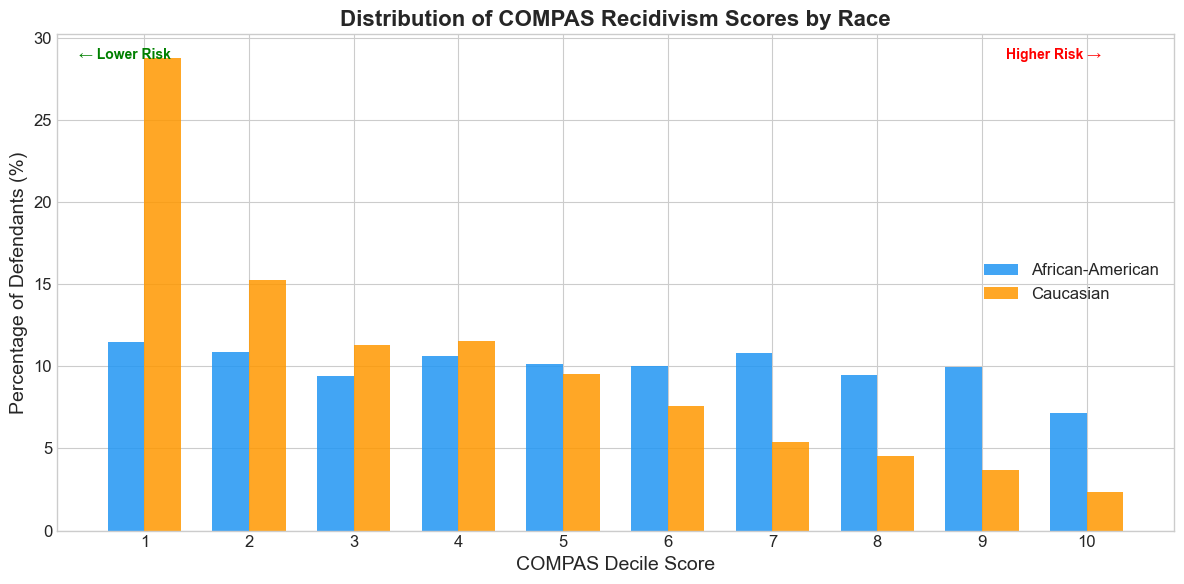


Key Observation: African-American defendants are more concentrated
in higher decile scores, while Caucasian defendants are more
concentrated in lower decile scores.


In [6]:
# Create a side-by-side bar chart of COMPAS score distributions
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate the proportion of each decile score within each race
# (Using proportions so the groups are comparable despite different sizes)
scores = range(1, 11)
aa_props = [(df_aa['decile_score'] == s).mean() * 100 for s in scores]
ca_props = [(df_ca['decile_score'] == s).mean() * 100 for s in scores]

x = np.arange(len(scores))
width = 0.35

bars1 = ax.bar(x - width/2, aa_props, width, label='African-American', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, ca_props, width, label='Caucasian', color='#FF9800', alpha=0.85)

ax.set_xlabel('COMPAS Decile Score', fontsize=14)
ax.set_ylabel('Percentage of Defendants (%)', fontsize=14)
ax.set_title('Distribution of COMPAS Recidivism Scores by Race', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scores)
ax.legend(fontsize=12)

# Add a note about what high/low scores mean
ax.annotate('\u2190 Lower Risk', xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=10, color='green', fontweight='bold')
ax.annotate('Higher Risk \u2192', xy=(0.85, 0.95), xycoords='axes fraction',
            fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('output/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observation: African-American defendants are more concentrated")
print("in higher decile scores, while Caucasian defendants are more")
print("concentrated in lower decile scores.")

In [7]:
# Show the score_text (Low/Medium/High) breakdown by race
print("=" * 50)
print("COMPAS Risk Category by Race")
print("=" * 50)

for race_label, race_df in [('African-American', df_aa), ('Caucasian', df_ca)]:
    print(f"\n{race_label}:")
    cat_counts = race_df['score_text'].value_counts()
    cat_pcts = race_df['score_text'].value_counts(normalize=True) * 100
    for cat in ['Low', 'Medium', 'High']:
        if cat in cat_counts.index:
            print(f"  {cat}: {cat_counts[cat]} ({cat_pcts[cat]:.1f}%)")

# Calculate the percentage labeled Medium or High risk
aa_high = (df_aa['score_text'].isin(['Medium', 'High'])).mean() * 100
ca_high = (df_ca['score_text'].isin(['Medium', 'High'])).mean() * 100
print(f"\nLabeled Medium or High Risk:")
print(f"  African-American: {aa_high:.1f}%")
print(f"  Caucasian: {ca_high:.1f}%")

COMPAS Risk Category by Race

African-American:
  Low: 1346 (42.4%)
  Medium: 984 (31.0%)
  High: 845 (26.6%)

Caucasian:
  Low: 1407 (66.9%)
  Medium: 473 (22.5%)
  High: 223 (10.6%)

Labeled Medium or High Risk:
  African-American: 57.6%
  Caucasian: 33.1%


---
## Section 4: Confusion Matrix Analysis by Race — The Core Finding

This is the **heart of ProPublica's analysis**. The question isn't just "are scores different?" — it's "**are the errors different?**"

### Setup
Following ProPublica's methodology:
- A defendant with `decile_score > 4` is classified as **"High Risk"** by COMPAS
- A defendant with `decile_score <= 4` is classified as **"Low Risk"**
- The ground truth is `two_year_recid` (1 = actually reoffended, 0 = did not)

### Key Metrics
- **False Positive Rate (FPR)**: Of those who did NOT reoffend, what % were incorrectly labeled High Risk? → *"Wrongly flagged as dangerous"*
- **False Negative Rate (FNR)**: Of those who DID reoffend, what % were incorrectly labeled Low Risk? → *"Wrongly labeled as safe"*
- **Overall Accuracy**: What % of predictions were correct?

In [8]:
# ============================================================
# Section 4: Confusion Matrix Analysis by Race
# ============================================================

# Following ProPublica: decile_score > 4 means "High Risk"
# This is the threshold ProPublica used in their analysis
THRESHOLD = 4

def analyze_compas_by_race(race_df, race_name):
    """
    Compute confusion matrix and error rates for a specific racial group.
    
    Parameters:
        race_df: DataFrame filtered to one racial group
        race_name: String label for printing
    
    Returns:
        Dictionary with FPR, FNR, and accuracy
    """
    # Ground truth: did the defendant actually reoffend?
    y_true = race_df['two_year_recid'].values
    
    # COMPAS prediction: score > 4 → predicted to reoffend ("High Risk")
    y_pred = (race_df['decile_score'] > THRESHOLD).astype(int).values
    
    # Compute confusion matrix
    # Format: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate rates
    fpr = fp / (fp + tn)  # False Positive Rate
    fnr = fn / (fn + tp)  # False Negative Rate
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Print results
    print(f"\n{'=' * 50}")
    print(f"  {race_name} Defendants (n={len(race_df)})")
    print(f"{'=' * 50}")
    print(f"\n  Confusion Matrix:")
    print(f"                        Predicted Low Risk   Predicted High Risk")
    print(f"  Did NOT reoffend:     {tn:>10}  (TN)      {fp:>10}  (FP)")
    print(f"  DID reoffend:         {fn:>10}  (FN)      {tp:>10}  (TP)")
    print(f"\n  Key Error Rates:")
    print(f"  → False Positive Rate (FPR): {fpr:.1%}")
    print(f"    (Of those who did NOT reoffend, {fpr:.1%} were wrongly labeled High Risk)")
    print(f"  → False Negative Rate (FNR): {fnr:.1%}")
    print(f"    (Of those who DID reoffend, {fnr:.1%} were wrongly labeled Low Risk)")
    print(f"  → Overall Accuracy: {accuracy:.1%}")
    
    return {'fpr': fpr, 'fnr': fnr, 'accuracy': accuracy, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

# Analyze both racial groups
aa_results = analyze_compas_by_race(df_aa, 'African-American')
ca_results = analyze_compas_by_race(df_ca, 'Caucasian')


  African-American Defendants (n=3175)

  Confusion Matrix:
                        Predicted Low Risk   Predicted High Risk
  Did NOT reoffend:            873  (TN)             641  (FP)
  DID reoffend:                473  (FN)            1188  (TP)

  Key Error Rates:
  → False Positive Rate (FPR): 42.3%
    (Of those who did NOT reoffend, 42.3% were wrongly labeled High Risk)
  → False Negative Rate (FNR): 28.5%
    (Of those who DID reoffend, 28.5% were wrongly labeled Low Risk)
  → Overall Accuracy: 64.9%

  Caucasian Defendants (n=2103)

  Confusion Matrix:
                        Predicted Low Risk   Predicted High Risk
  Did NOT reoffend:            999  (TN)             282  (FP)
  DID reoffend:                408  (FN)             414  (TP)

  Key Error Rates:
  → False Positive Rate (FPR): 22.0%
    (Of those who did NOT reoffend, 22.0% were wrongly labeled High Risk)
  → False Negative Rate (FNR): 49.6%
    (Of those who DID reoffend, 49.6% were wrongly labeled Low Risk)
 

In [9]:
# Print a clear side-by-side comparison of the racial disparity
print("\n" + "=" * 60)
print("  SIDE-BY-SIDE COMPARISON: COMPAS Error Rates by Race")
print("=" * 60)
print(f"\n{'Metric':<30} {'African-American':>18} {'Caucasian':>12}")
print(f"{'-'*60}")
print(f"{'False Positive Rate (FPR)':<30} {aa_results['fpr']:>17.1%} {ca_results['fpr']:>11.1%}")
print(f"{'False Negative Rate (FNR)':<30} {aa_results['fnr']:>17.1%} {ca_results['fnr']:>11.1%}")
print(f"{'Overall Accuracy':<30} {aa_results['accuracy']:>17.1%} {ca_results['accuracy']:>11.1%}")

print(f"\n{'KEY DISPARITY':}")
print(f"  FPR ratio (Black / White): {aa_results['fpr'] / ca_results['fpr']:.2f}x")
print(f"  → Black defendants are ~{aa_results['fpr'] / ca_results['fpr']:.1f}x more likely to be")
print(f"    FALSELY labeled as high risk compared to white defendants")
print(f"\n  FNR ratio (White / Black): {ca_results['fnr'] / aa_results['fnr']:.2f}x")
print(f"  → White defendants are ~{ca_results['fnr'] / aa_results['fnr']:.1f}x more likely to be")
print(f"    FALSELY labeled as low risk compared to black defendants")


  SIDE-BY-SIDE COMPARISON: COMPAS Error Rates by Race

Metric                           African-American    Caucasian
------------------------------------------------------------
False Positive Rate (FPR)                  42.3%       22.0%
False Negative Rate (FNR)                  28.5%       49.6%
Overall Accuracy                           64.9%       67.2%

KEY DISPARITY
  FPR ratio (Black / White): 1.92x
  → Black defendants are ~1.9x more likely to be
    FALSELY labeled as high risk compared to white defendants

  FNR ratio (White / Black): 1.74x
  → White defendants are ~1.7x more likely to be
    FALSELY labeled as low risk compared to black defendants


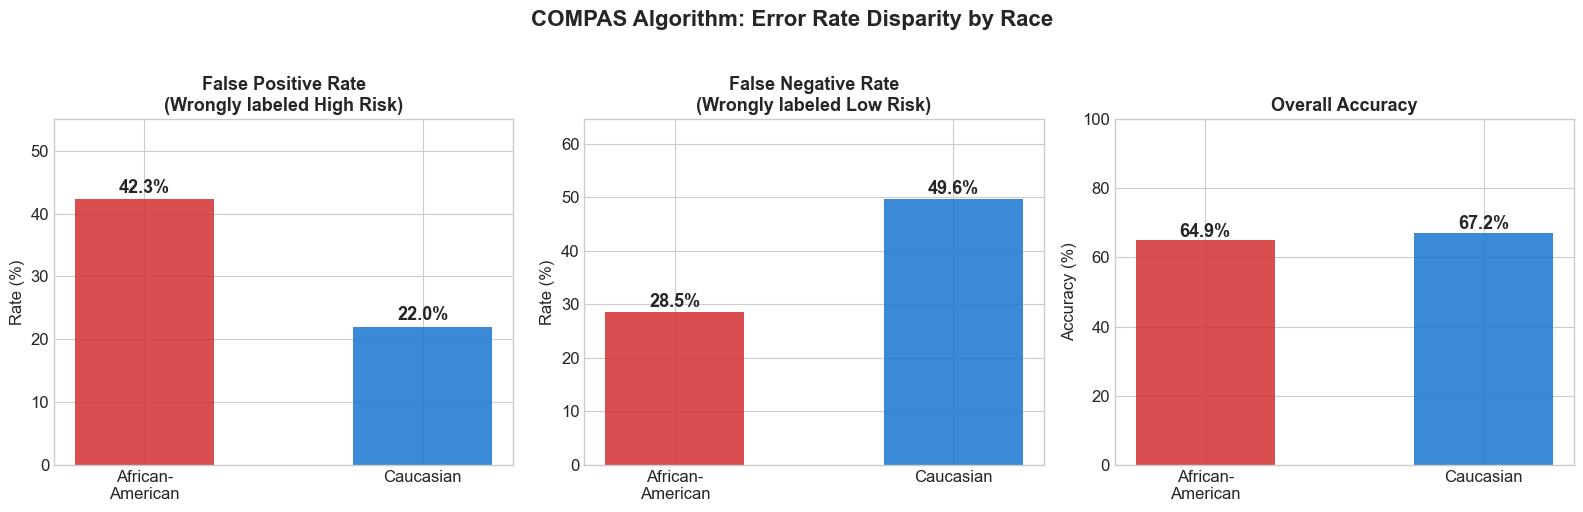

The charts clearly show: while overall accuracy is similar,
the TYPES of errors are very different across racial groups.


In [10]:
# Visualize the disparity in error rates
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Chart 1: False Positive Rate ---
races = ['African-\nAmerican', 'Caucasian']
fpr_values = [aa_results['fpr'] * 100, ca_results['fpr'] * 100]
colors_fpr = ['#D32F2F', '#1976D2']  # Red and blue

bars1 = axes[0].bar(races, fpr_values, color=colors_fpr, alpha=0.85, width=0.5)
axes[0].set_title('False Positive Rate\n(Wrongly labeled High Risk)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rate (%)', fontsize=12)
axes[0].set_ylim(0, max(fpr_values) * 1.3)
# Add value labels on bars
for bar, val in zip(bars1, fpr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# --- Chart 2: False Negative Rate ---
fnr_values = [aa_results['fnr'] * 100, ca_results['fnr'] * 100]
colors_fnr = ['#D32F2F', '#1976D2']

bars2 = axes[1].bar(races, fnr_values, color=colors_fnr, alpha=0.85, width=0.5)
axes[1].set_title('False Negative Rate\n(Wrongly labeled Low Risk)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rate (%)', fontsize=12)
axes[1].set_ylim(0, max(fnr_values) * 1.3)
for bar, val in zip(bars2, fnr_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# --- Chart 3: Overall Accuracy ---
acc_values = [aa_results['accuracy'] * 100, ca_results['accuracy'] * 100]
colors_acc = ['#D32F2F', '#1976D2']

bars3 = axes[2].bar(races, acc_values, color=colors_acc, alpha=0.85, width=0.5)
axes[2].set_title('Overall Accuracy', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_ylim(0, 100)
for bar, val in zip(bars3, acc_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('COMPAS Algorithm: Error Rate Disparity by Race', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/error_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("The charts clearly show: while overall accuracy is similar,")
print("the TYPES of errors are very different across racial groups.")

---
## Section 5: Logistic Regression Model

Now we train a simple **logistic regression** model to predict recidivism. The goal is to:
1. See if a basic model can achieve accuracy comparable to COMPAS
2. Demonstrate that simple, transparent models can perform similarly to opaque commercial tools

### Feature Selection
We intentionally **do NOT include race** as a feature. We use:
- `age` — defendant's age at screening
- `priors_count` — number of prior offenses
- `c_charge_degree` — severity of the current charge (Felony or Misdemeanor)

This lets us ask: can a race-blind model still predict recidivism effectively?

In [11]:
# ============================================================
# Section 5: Logistic Regression Model
# ============================================================

# Prepare the features (X) and target variable (y)
# We use the full filtered dataset (all races) for training

# Encode charge degree: 'F' (Felony) → 1, 'M' (Misdemeanor) → 0
df['charge_degree_binary'] = (df['c_charge_degree'] == 'F').astype(int)

# Define features — NOTE: race is intentionally excluded!
feature_cols = ['age', 'priors_count', 'charge_degree_binary']
X = df[feature_cols].copy()
y = df['two_year_recid'].copy()

print("Features used for logistic regression:")
print(f"  1. age — defendant's age (continuous)")
print(f"  2. priors_count — number of prior offenses (continuous)")
print(f"  3. charge_degree_binary — felony=1, misdemeanor=0 (binary)")
print(f"  *** Race is NOT included as a feature ***")
print(f"\nDataset size: {len(X)} samples")
print(f"Recidivism rate: {y.mean():.1%}")

# Split into training (70%) and test (30%) sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Features used for logistic regression:
  1. age — defendant's age (continuous)
  2. priors_count — number of prior offenses (continuous)
  3. charge_degree_binary — felony=1, misdemeanor=0 (binary)
  *** Race is NOT included as a feature ***

Dataset size: 6172 samples
Recidivism rate: 45.5%

Training set: 4320 samples
Test set: 1852 samples


In [12]:
# Train the logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nTest Set Accuracy: {lr_accuracy:.1%}")

# Show the model's coefficients (how each feature affects the prediction)
print(f"\nModel Coefficients (how each feature affects risk prediction):")
for feature, coef in zip(feature_cols, model.coef_[0]):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f"  {feature}: {coef:+.4f} — higher values {direction} predicted risk")
print(f"  intercept: {model.intercept_[0]:+.4f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Recidivism', 'Recidivism']))

LOGISTIC REGRESSION RESULTS

Test Set Accuracy: 67.4%

Model Coefficients (how each feature affects risk prediction):
  age: -0.0439 — higher values decreases predicted risk
  priors_count: +0.1779 — higher values increases predicted risk
  charge_degree_binary: +0.3007 — higher values increases predicted risk
  intercept: +0.5850

Detailed Classification Report:
               precision    recall  f1-score   support

No Recidivism       0.68      0.78      0.73      1020
   Recidivism       0.67      0.54      0.60       832

     accuracy                           0.67      1852
    macro avg       0.67      0.66      0.66      1852
 weighted avg       0.67      0.67      0.67      1852



In [13]:
# Confusion matrix for the logistic regression model
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_test, y_pred).ravel()

fpr_lr = fp_lr / (fp_lr + tn_lr)
fnr_lr = fn_lr / (fn_lr + tp_lr)

print("Logistic Regression Confusion Matrix:")
print(f"                        Predicted No Recid   Predicted Recid")
print(f"  Did NOT reoffend:     {tn_lr:>10}  (TN)      {fp_lr:>10}  (FP)")
print(f"  DID reoffend:         {fn_lr:>10}  (FN)      {tp_lr:>10}  (TP)")
print(f"\n  False Positive Rate: {fpr_lr:.1%}")
print(f"  False Negative Rate: {fnr_lr:.1%}")
print(f"  Overall Accuracy: {lr_accuracy:.1%}")

Logistic Regression Confusion Matrix:
                        Predicted No Recid   Predicted Recid
  Did NOT reoffend:            797  (TN)             223  (FP)
  DID reoffend:                381  (FN)             451  (TP)

  False Positive Rate: 21.9%
  False Negative Rate: 45.8%
  Overall Accuracy: 67.4%


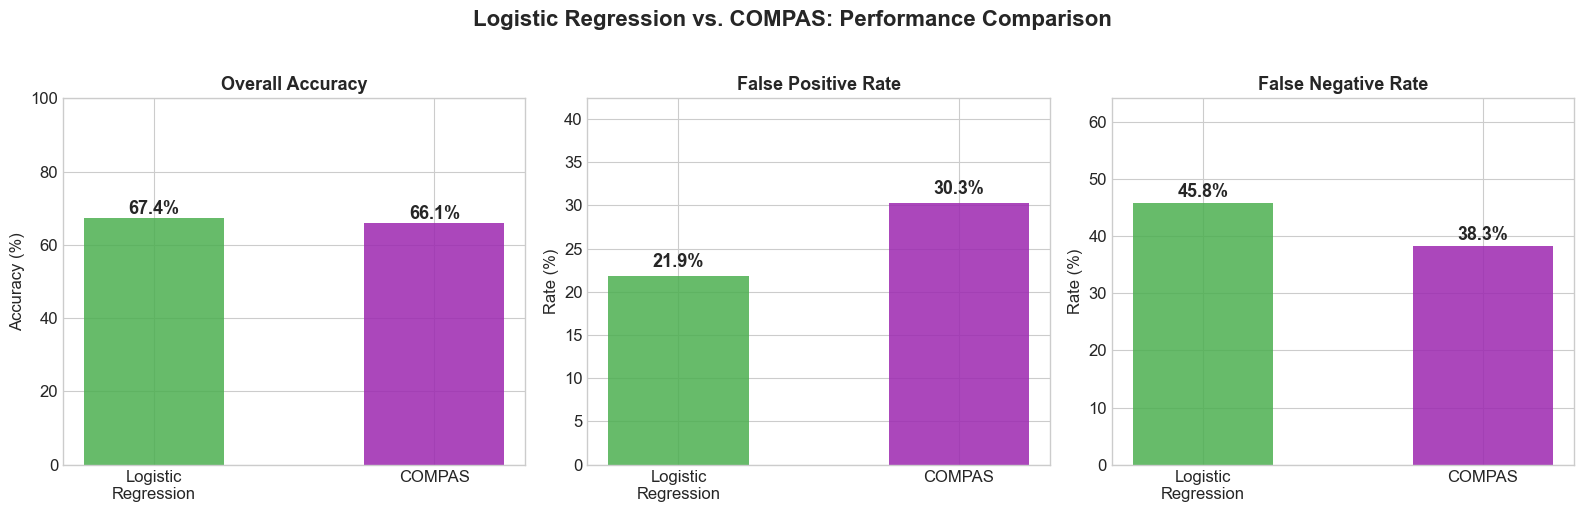

  COMPARISON: Logistic Regression vs. COMPAS

Metric                          Logistic Regression     COMPAS
------------------------------------------------------------
Overall Accuracy                             67.4%     66.1%

Key Insight: A simple 3-feature logistic regression achieves
accuracy comparable to the proprietary COMPAS algorithm, raising
questions about whether the complexity (and opacity) of COMPAS
is justified.


In [14]:
# ============================================================
# Compare Logistic Regression vs COMPAS — Visual Comparison
# ============================================================

# Calculate COMPAS overall accuracy on the full filtered dataset (all races)
compas_pred_all = (df['decile_score'] > THRESHOLD).astype(int)
compas_accuracy_all = accuracy_score(df['two_year_recid'], compas_pred_all)

# Also compute COMPAS FPR/FNR on full dataset for comparison
tn_compas, fp_compas, fn_compas, tp_compas = confusion_matrix(df['two_year_recid'], compas_pred_all).ravel()
fpr_compas_all = fp_compas / (fp_compas + tn_compas)
fnr_compas_all = fn_compas / (fn_compas + tp_compas)

# Create a grouped bar chart comparing the two models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['Logistic\nRegression', 'COMPAS']
colors = ['#4CAF50', '#9C27B0']

# Chart 1: Accuracy
acc_vals = [lr_accuracy * 100, compas_accuracy_all * 100]
bars1 = axes[0].bar(models, acc_vals, color=colors, alpha=0.85, width=0.5)
axes[0].set_title('Overall Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Chart 2: False Positive Rate
fpr_vals = [fpr_lr * 100, fpr_compas_all * 100]
bars2 = axes[1].bar(models, fpr_vals, color=colors, alpha=0.85, width=0.5)
axes[1].set_title('False Positive Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rate (%)', fontsize=12)
axes[1].set_ylim(0, max(fpr_vals) * 1.4)
for bar, val in zip(bars2, fpr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Chart 3: False Negative Rate
fnr_vals = [fnr_lr * 100, fnr_compas_all * 100]
bars3 = axes[2].bar(models, fnr_vals, color=colors, alpha=0.85, width=0.5)
axes[2].set_title('False Negative Rate', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Rate (%)', fontsize=12)
axes[2].set_ylim(0, max(fnr_vals) * 1.4)
for bar, val in zip(bars3, fnr_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Logistic Regression vs. COMPAS: Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("  COMPARISON: Logistic Regression vs. COMPAS")
print("=" * 60)
print(f"\n{'Metric':<30} {'Logistic Regression':>20} {'COMPAS':>10}")
print(f"{'-' * 60}")
print(f"{'Overall Accuracy':<30} {lr_accuracy:>19.1%} {compas_accuracy_all:>9.1%}")
print(f"\nKey Insight: A simple 3-feature logistic regression achieves")
print(f"accuracy comparable to the proprietary COMPAS algorithm, raising")
print(f"questions about whether the complexity (and opacity) of COMPAS")
print(f"is justified.")

---
## Section 6: Key Findings Summary

### Finding 1: Racial Disparity in Score Distribution
African-American defendants receive systematically **higher** COMPAS risk scores than Caucasian defendants. A much larger proportion of Black defendants are classified as "Medium" or "High" risk.

### Finding 2: Asymmetric Error Rates (The Core Issue)
While COMPAS has roughly **similar overall accuracy** for both groups, the **types of errors are systematically different**:

| Metric | African-American | Caucasian |
|--------|:---:|:---:|
| **False Positive Rate** (wrongly labeled dangerous) | **~2x higher** | Lower |
| **False Negative Rate** (wrongly labeled safe) | Lower | **~2x higher** |
| Overall Accuracy | Similar | Similar |

**In plain language:**
- Black defendants who will NOT go on to reoffend are much more likely to be flagged as high risk
- White defendants who WILL go on to reoffend are much more likely to be labeled low risk

### Finding 3: A Simple Model Performs Comparably
A basic logistic regression using only **age, prior offenses, and charge severity** (with NO race information) achieves accuracy comparable to COMPAS. This suggests that the proprietary, opaque COMPAS system may not offer significant predictive advantages over simpler, more transparent approaches.

### Policy Implications
1. **Algorithmic fairness is not just about overall accuracy** — the distribution of errors matters enormously when those errors affect people's liberty.
2. **Opacity without accuracy gains is hard to justify** — if simple models perform similarly, why use a black box?
3. **Equal accuracy ≠ equal treatment** — COMPAS shows that an algorithm can be equally accurate across groups while still being systematically biased in *how* it errs.

In [15]:
# ============================================================
# Final Summary: Print all key numbers in one place
# ============================================================

print("\n" + "#" * 70)
print("#" + " " * 68 + "#")
print("#    COMPAS RECIDIVISM ANALYSIS — COMPLETE RESULTS SUMMARY" + " " * 11 + "#")
print("#" + " " * 68 + "#")
print("#" * 70)

print(f"\n📊 DATASET")
print(f"   Raw records: {len(df_raw)}")
print(f"   After ProPublica filtering: {len(df)}")
print(f"   African-American defendants: {len(df_aa)}")
print(f"   Caucasian defendants: {len(df_ca)}")

print(f"\n📈 COMPAS SCORES")
print(f"   Mean score (African-American): {df_aa['decile_score'].mean():.2f}")
print(f"   Mean score (Caucasian): {df_ca['decile_score'].mean():.2f}")

print(f"\n⚖️  ERROR RATE DISPARITY (COMPAS, threshold > {THRESHOLD})")
print(f"   False Positive Rate:")
print(f"     African-American: {aa_results['fpr']:.1%}")
print(f"     Caucasian:        {ca_results['fpr']:.1%}")
print(f"     Ratio:            {aa_results['fpr']/ca_results['fpr']:.2f}x")
print(f"   False Negative Rate:")
print(f"     African-American: {aa_results['fnr']:.1%}")
print(f"     Caucasian:        {ca_results['fnr']:.1%}")
print(f"     Ratio:            {ca_results['fnr']/aa_results['fnr']:.2f}x")

print(f"\n🤖 MODEL COMPARISON")
print(f"   COMPAS overall accuracy: {compas_accuracy_all:.1%}")
print(f"   Logistic Regression accuracy: {lr_accuracy:.1%}")
print(f"   (LR uses only: age, priors_count, charge_degree — no race)")

print(f"\n" + "#" * 70)
print(f"Analysis complete. This replicates ProPublica's core findings.")
print(f"#" * 70)


######################################################################
#                                                                    #
#    COMPAS RECIDIVISM ANALYSIS — COMPLETE RESULTS SUMMARY           #
#                                                                    #
######################################################################

📊 DATASET
   Raw records: 7214
   After ProPublica filtering: 6172
   African-American defendants: 3175
   Caucasian defendants: 2103

📈 COMPAS SCORES
   Mean score (African-American): 5.28
   Mean score (Caucasian): 3.64

⚖️  ERROR RATE DISPARITY (COMPAS, threshold > 4)
   False Positive Rate:
     African-American: 42.3%
     Caucasian:        22.0%
     Ratio:            1.92x
   False Negative Rate:
     African-American: 28.5%
     Caucasian:        49.6%
     Ratio:            1.74x

🤖 MODEL COMPARISON
   COMPAS overall accuracy: 66.1%
   Logistic Regression accuracy: 67.4%
   (LR uses only: age, priors_count, charge_degree — no 